<center>

# ML: High Dimensional Viz - T-SNE : 18th September 2023

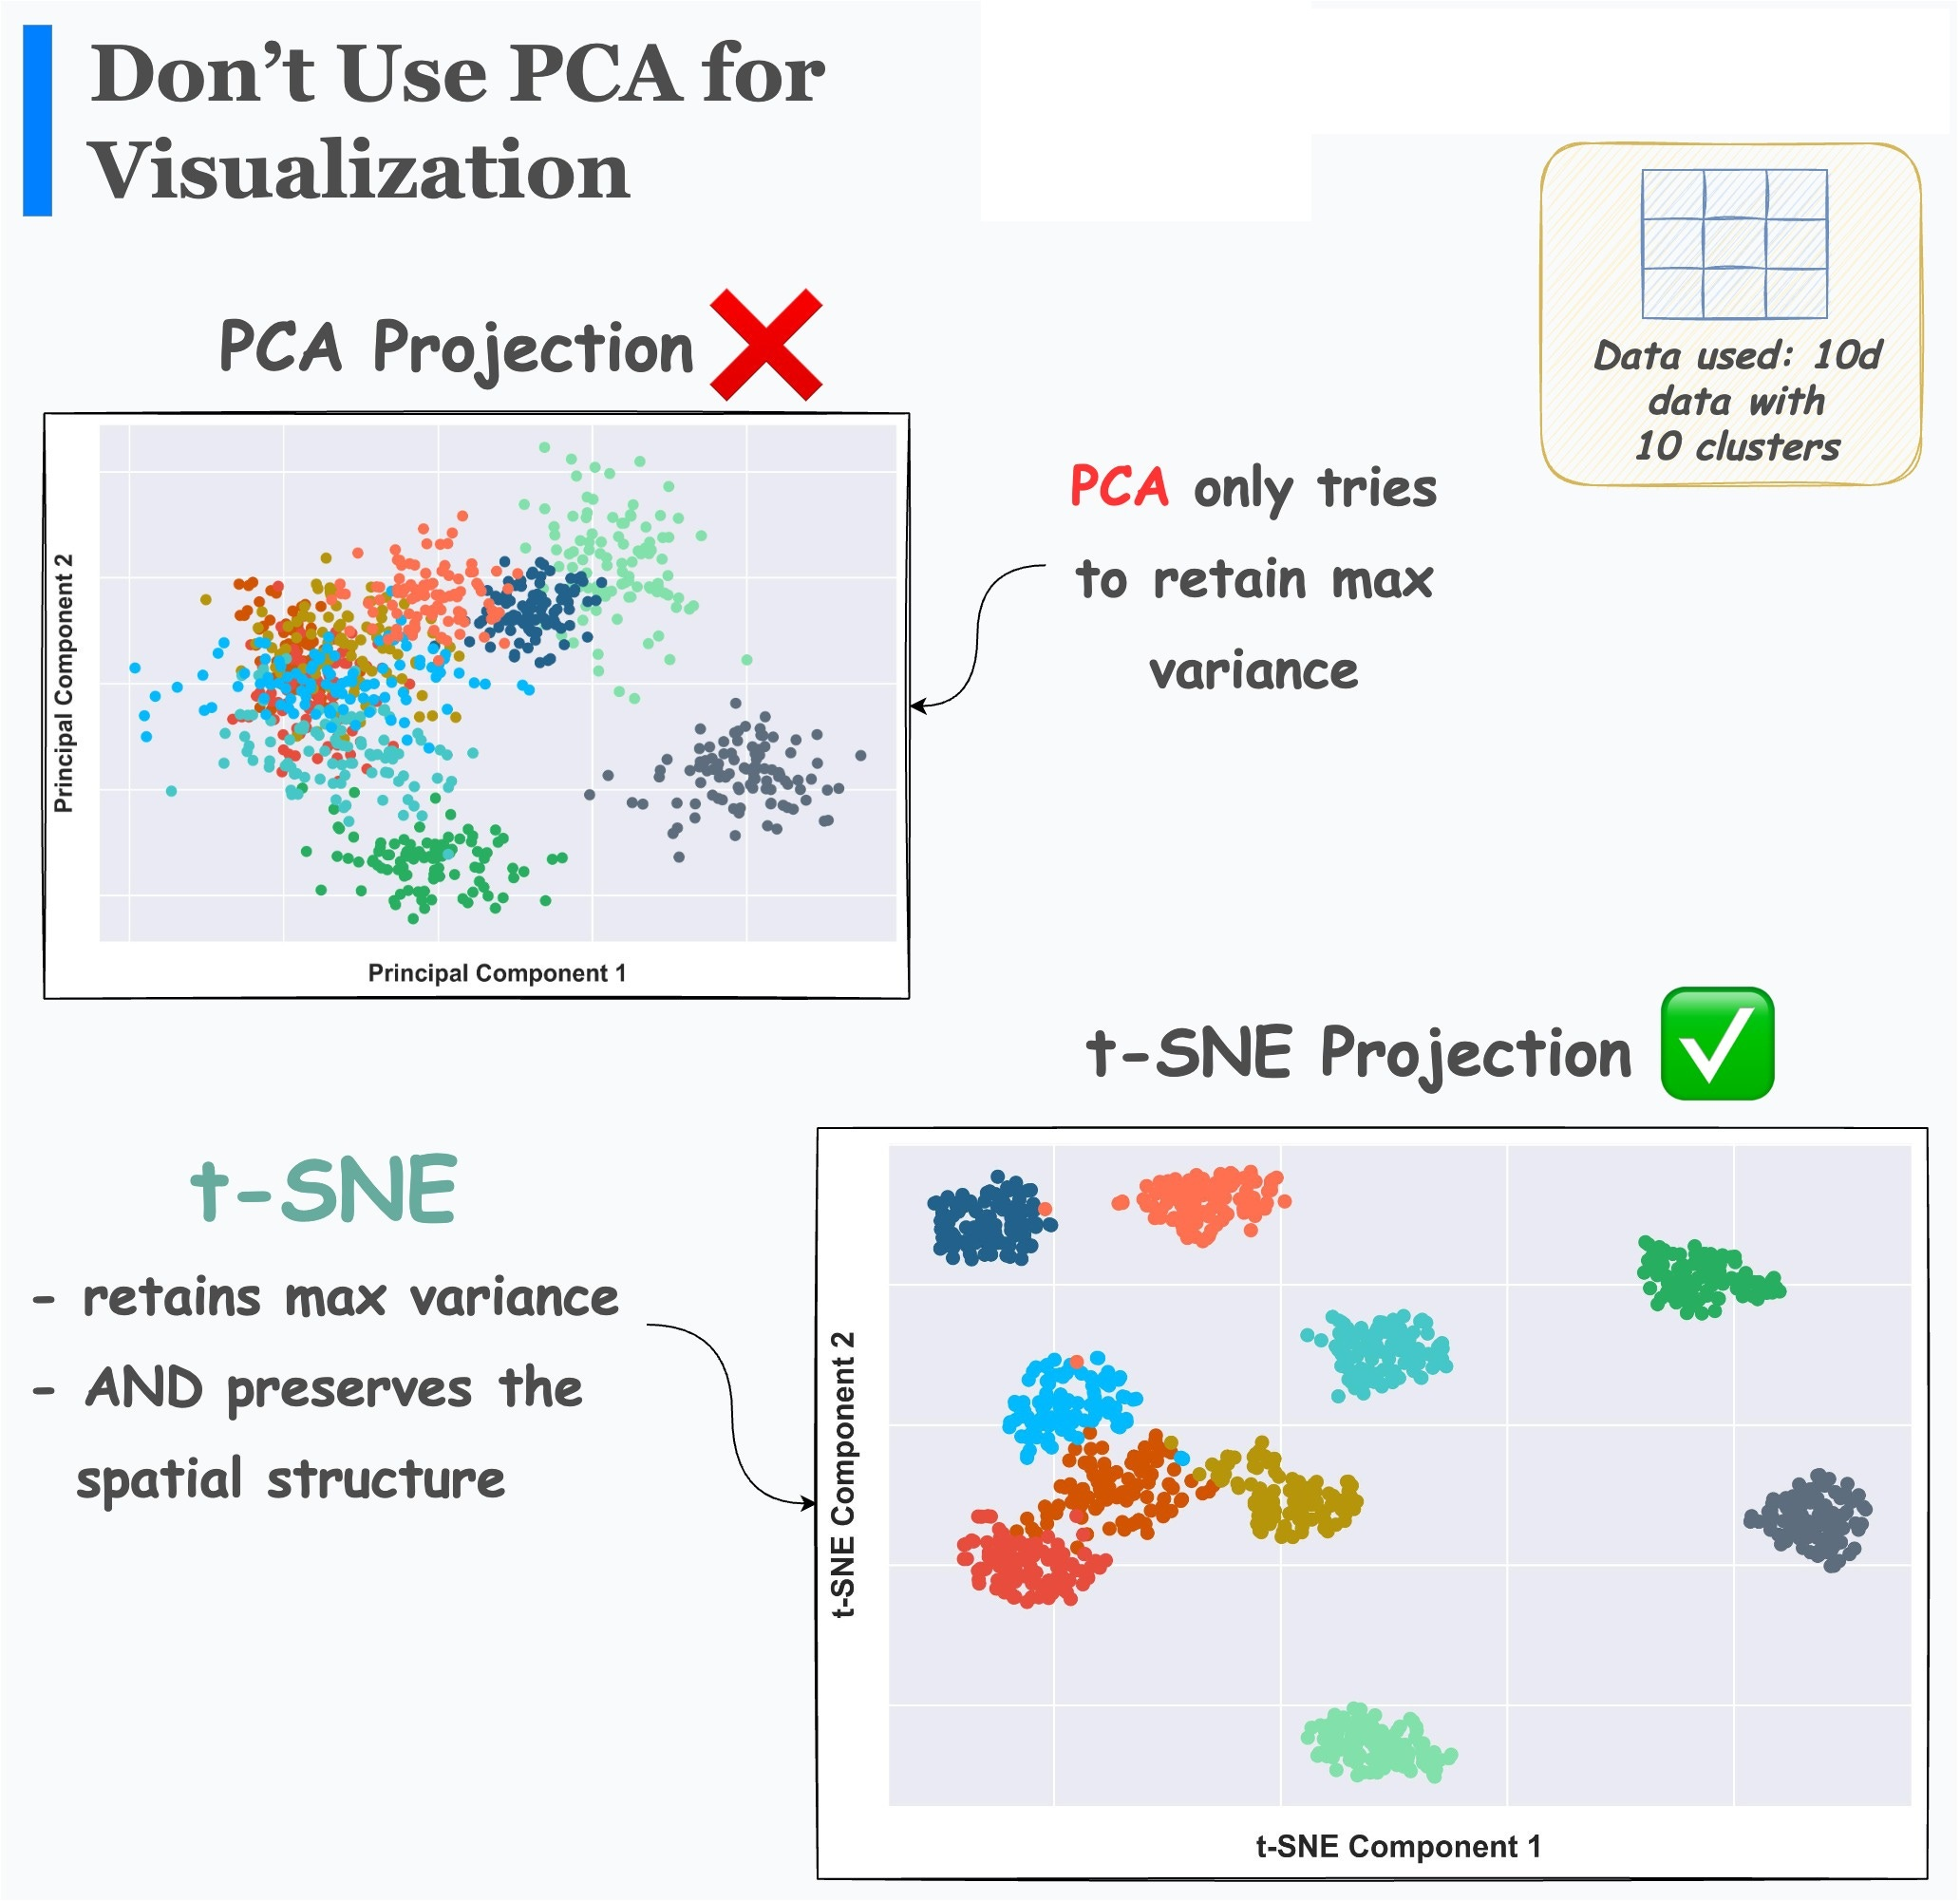

## Principal component analysis (PCA)

### Code implemetnation: PCA from scratch

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
!gdown 16elpyaPZhS63ibzIdetEjZhCO4FpVSZu

Downloading...
From: https://drive.google.com/uc?id=16elpyaPZhS63ibzIdetEjZhCO4FpVSZu
To: /content/pca_2d_data.csv
100% 778/778 [00:00<00:00, 1.89MB/s]


In [ ]:
data = pd.read_csv('/content/pca_2d_data.csv')
data.head()

,f1,f2
0,2.038772,1.102760
1,0.869536,0.238030
2,1.795888,1.020364
3,0.103510,-0.513661
4,1.479554,0.750702


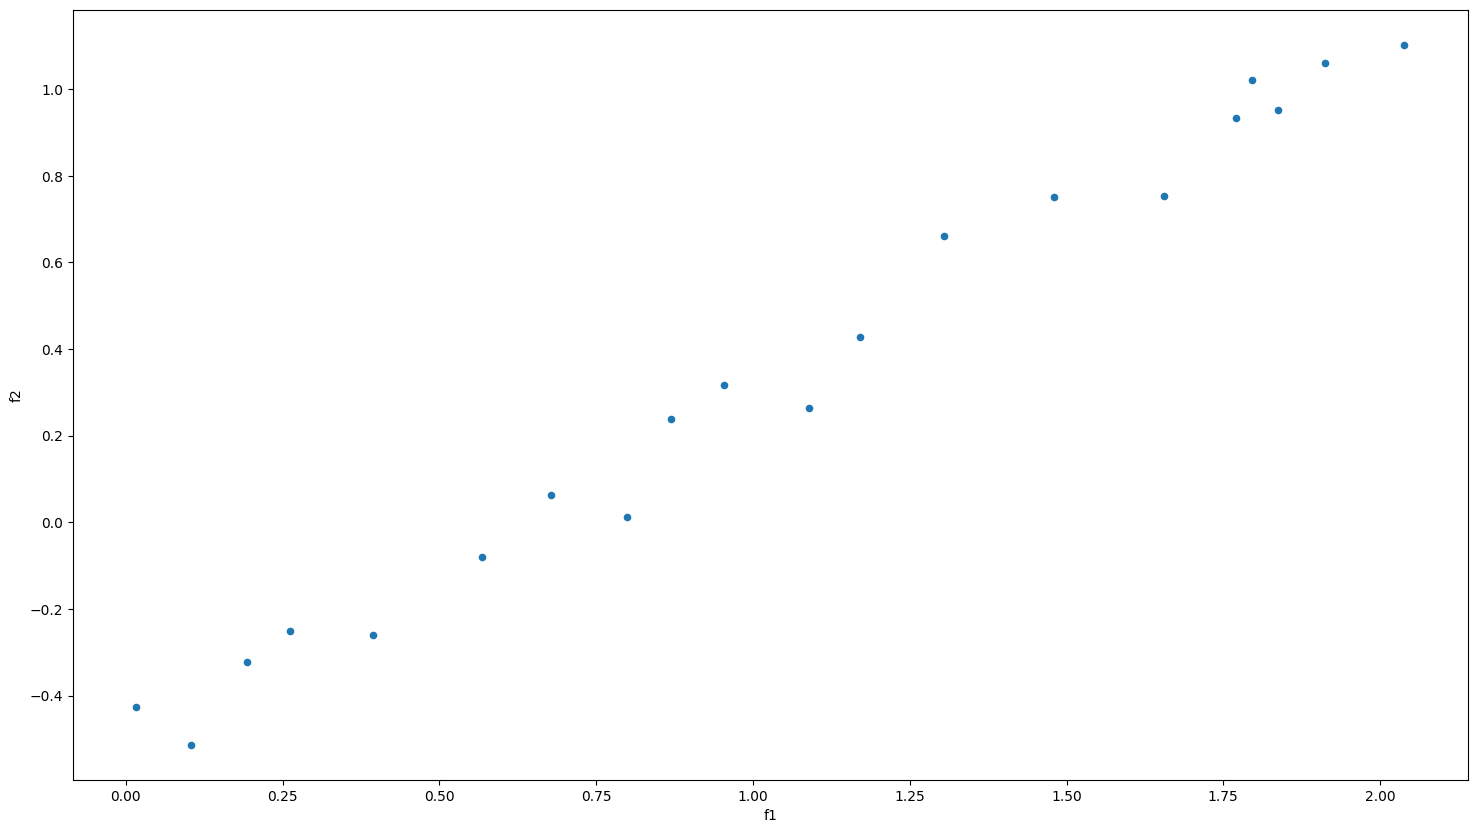

In [ ]:
data.plot(x='f1', y='f2', kind='scatter')
plt.show()

In [ ]:
## Implement PCA!!
# Step 1: Column standardization
x_data = data['f1'].values
y_data = data['f2'].values

mean_x = np.mean(x_data)
mean_y = np.mean(y_data)

std_x = np.std(x_data)
std_y = np.std(y_data)

x_data_cs = (x_data - mean_x) / std_x
y_data_cs = (y_data - mean_y) / std_y

X_st = np.zeros((len(x_data), 2))
X_st[:, 0] = x_data_cs
X_st[:, 1] = y_data_cs


In [ ]:
# Step 2: Eigenvalue decomposition
# https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

cov_X_st = np.matmul(X_st.T, X_st) / (len(x_data)-1)
eigenvalues, eigenvectors = np.linalg.eig(cov_X_st)

eigenvectors = eigenvectors.T  #  thats how we want them (horizontal)
# The normalized (unit “length”) eigenvectors,
# such that the column eigenvectors[:,i]
# is the eigenvector corresponding to the eigenvalue eigenvalues[i].
print(eigenvectors)
print("-=-"*20, "just a seperator")
print(eigenvalues)

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
-=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=- just a seperator
[2.09718701 0.00807615]


In [ ]:
# Step 3: Reduce the dimension! Choose the eigenvector corresponding to the largest eigenvalue
X_prime = eigenvectors[0].dot(X_st.T)
X_prime_reduced = X_prime

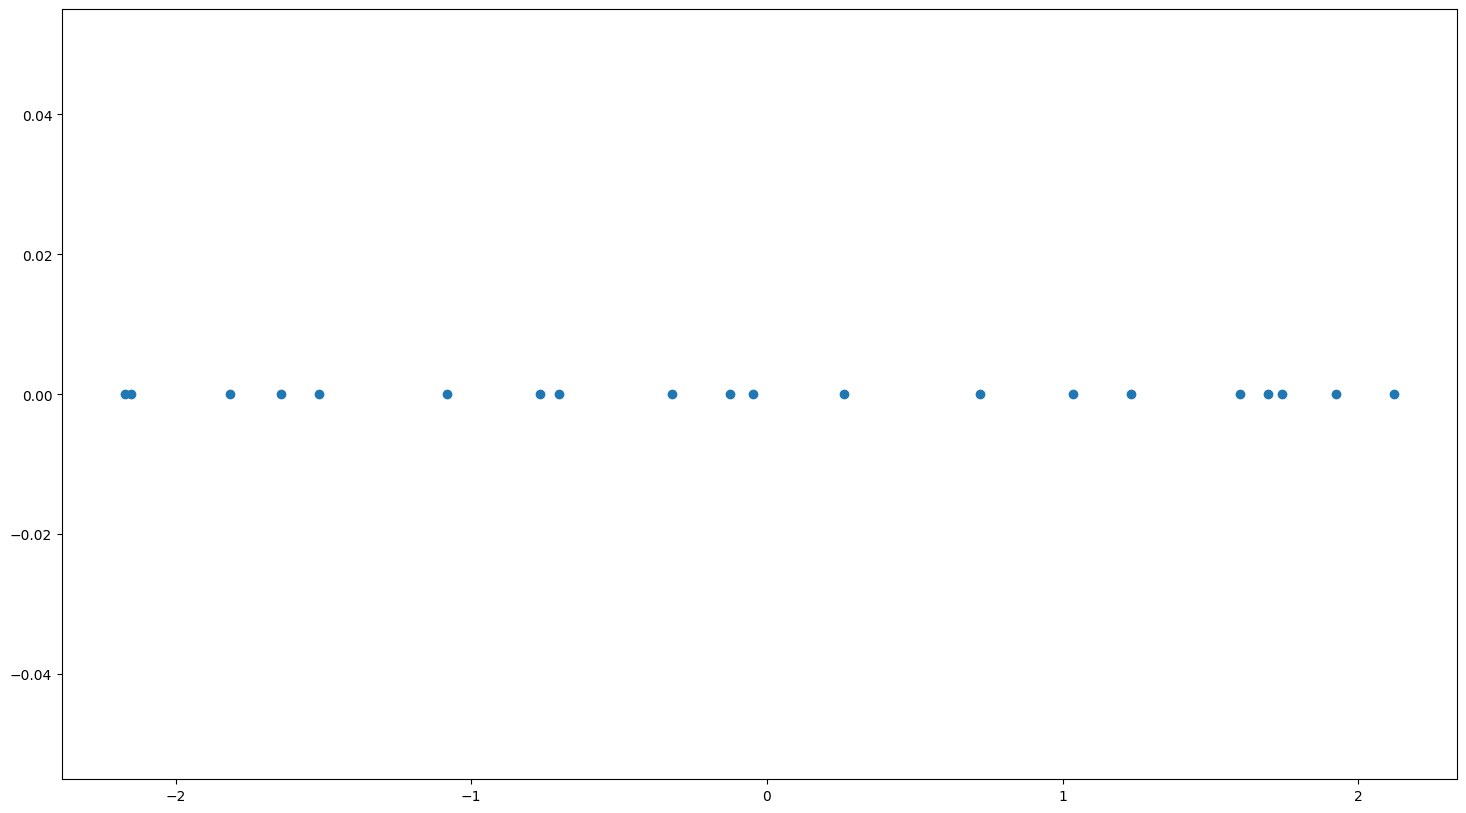

In [ ]:
# Step 4: Visualize
plt.figure()
plt.scatter(X_prime_reduced, np.zeros((len(x_data),)))
plt.show()

In [ ]:
# explained var == eigenvalues
print(eigenvalues)
# explained var ration
eigenvalues[0]/eigenvalues.sum()

[2.09718701 0.00807615]


0.9961638305134559

### PCA impl: using helper libraries

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
-=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=--=- just a seperator
[2.09718701 0.00807615]


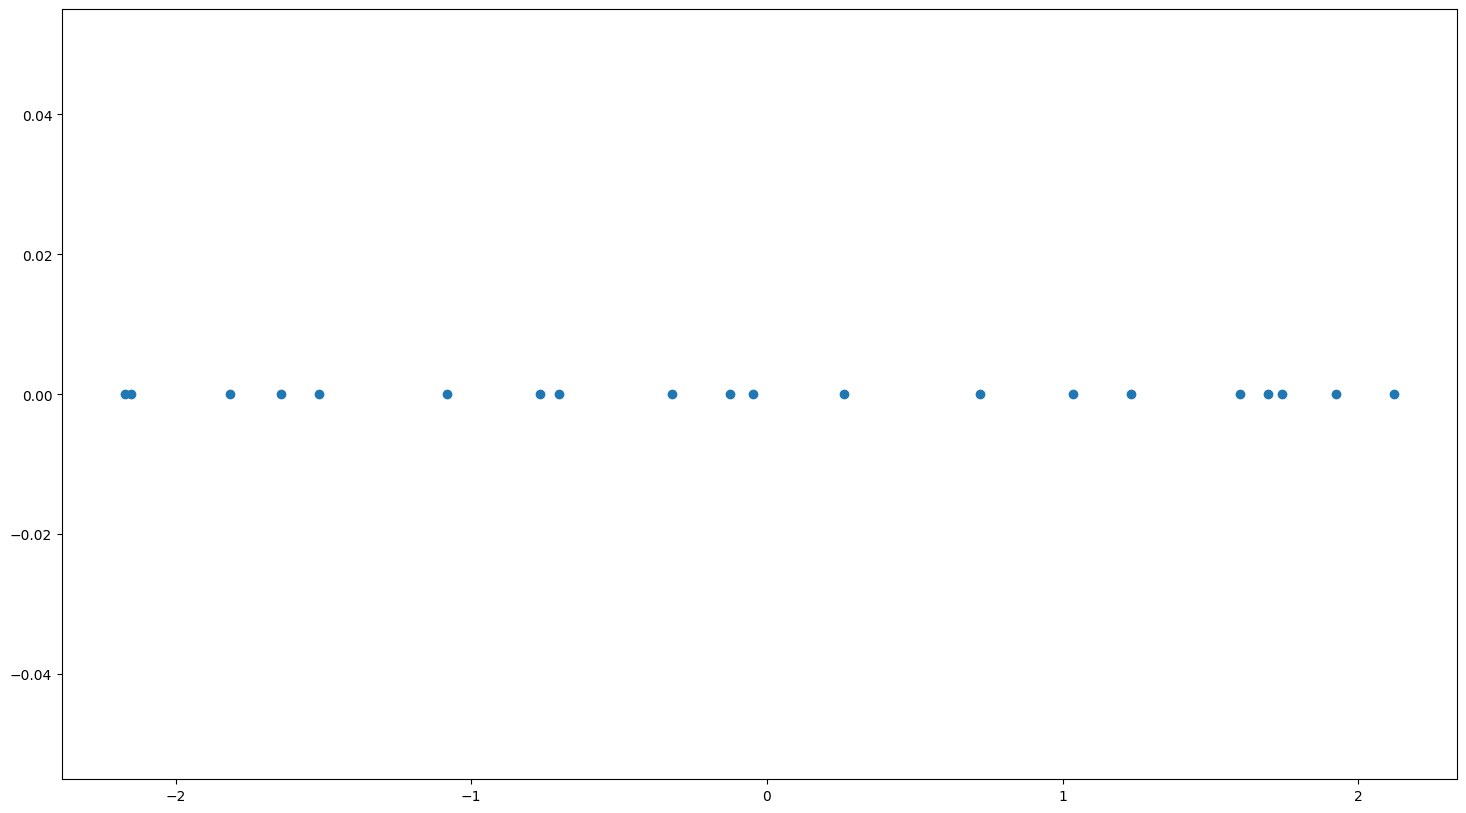

In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 1: Column standardization
data_sc = StandardScaler().fit_transform(data)

# Step 2: Eigenvalue decomposition
cov = np.cov(data_sc.T)
eigenvalues, eigenvectors = np.linalg.eig(cov)
eigenvectors = eigenvectors.T # We want like this, every row as a eigenvectors
print(eigenvectors)
print("-=-"*20, "just a seperator")
print(eigenvalues)

# Step 3: Reduce the dimension! Choose the eigenvector corresponding to the largest eigenvalue
X_prime_reduced = eigenvectors[0].dot(data_sc.T)

# Step 4: Visualize
plt.figure()
plt.scatter(X_prime_reduced, np.zeros((len(data_sc),)))
plt.show()

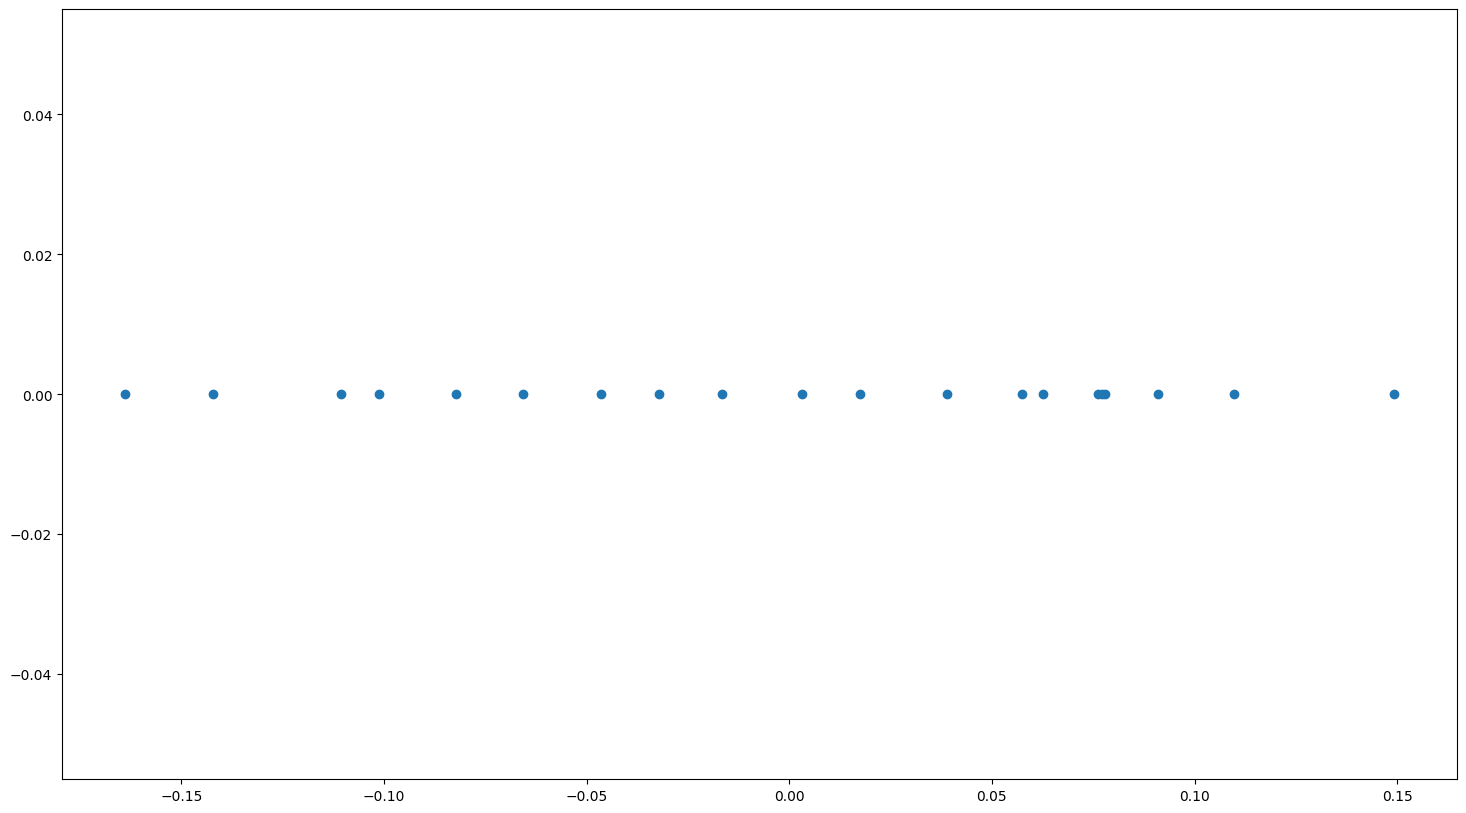

In [ ]:
# Step 3: Reduce the dimension! Choose the eigenvector corresponding to the largest eigenvalue
X_prime_reduced = eigenvectors[1].dot(data_sc.T)

# Step 4: Visualize
plt.figure()
plt.scatter(X_prime_reduced, np.zeros((len(data_sc),)))
plt.show()

In [ ]:
# explained variance
eigenvalues[0] / eigenvalues.sum()

0.9961638305134559

### sklearn.decomposition.PCA

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
from sklearn import decomposition


pca = decomposition.PCA(n_components=2)

X_p = pca.fit_transform(data_sc)

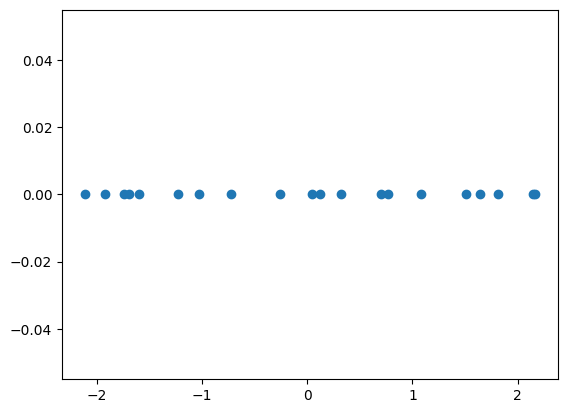

In [ ]:
plt.figure()
plt.scatter(X_p[:, 0], np.zeros((len(data_sc),)))
plt.show()

In [ ]:
pca.components_

array([[-0.70710678, -0.70710678],
       [ 0.70710678, -0.70710678]])

In [ ]:
pca.explained_variance_

array([2.09718701, 0.00807615])

In [ ]:
pca.explained_variance_ratio_

array([0.99616383, 0.00383617])

## Usecase: High Dimensional Visualization

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = (18,10)
from matplotlib.pyplot import cm
import seaborn as sns

In [ ]:
# Loading dataset
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
Y = digits.target
print(digits.keys())


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [ ]:
print(X.shape)
print(Y.shape)
print(np.unique(Y))
print(digits.images.shape) # 8 x 8  image results into 64 features

(1797, 64)
(1797,)
[0 1 2 3 4 5 6 7 8 9]
(1797, 8, 8)


1


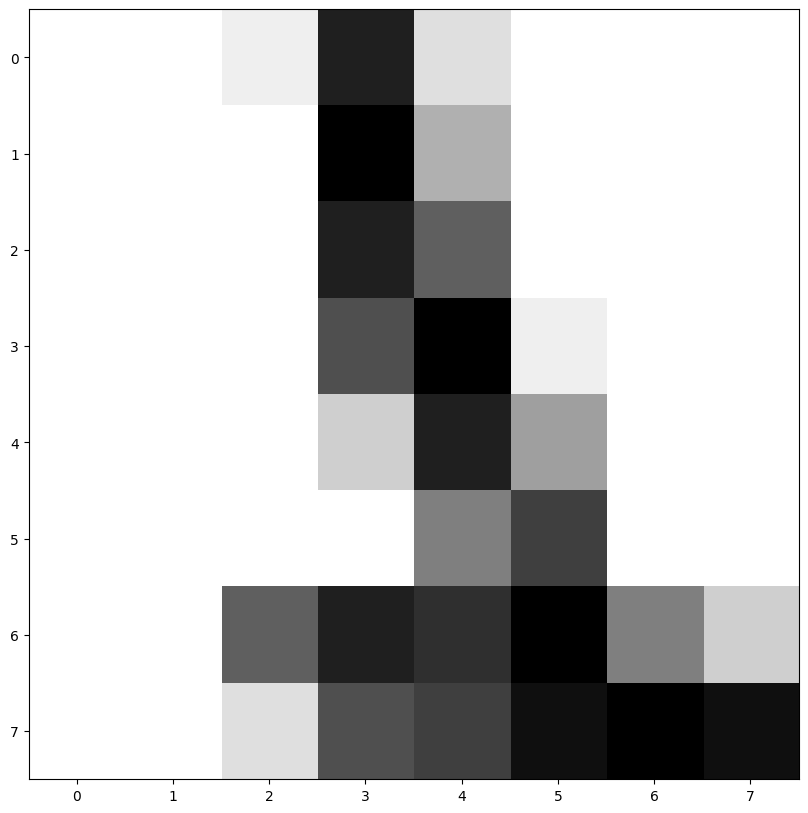

In [ ]:
plt.gray()
print(Y[1000])
plt.imshow(digits.images[1000], cmap=plt.cm.gray_r)

### PCA for visualisation

In [ ]:
from sklearn import decomposition

pca_2D = decomposition.PCA(n_components=2)
pca_2D.fit(X)
Z1 = pca_2D.transform(X)

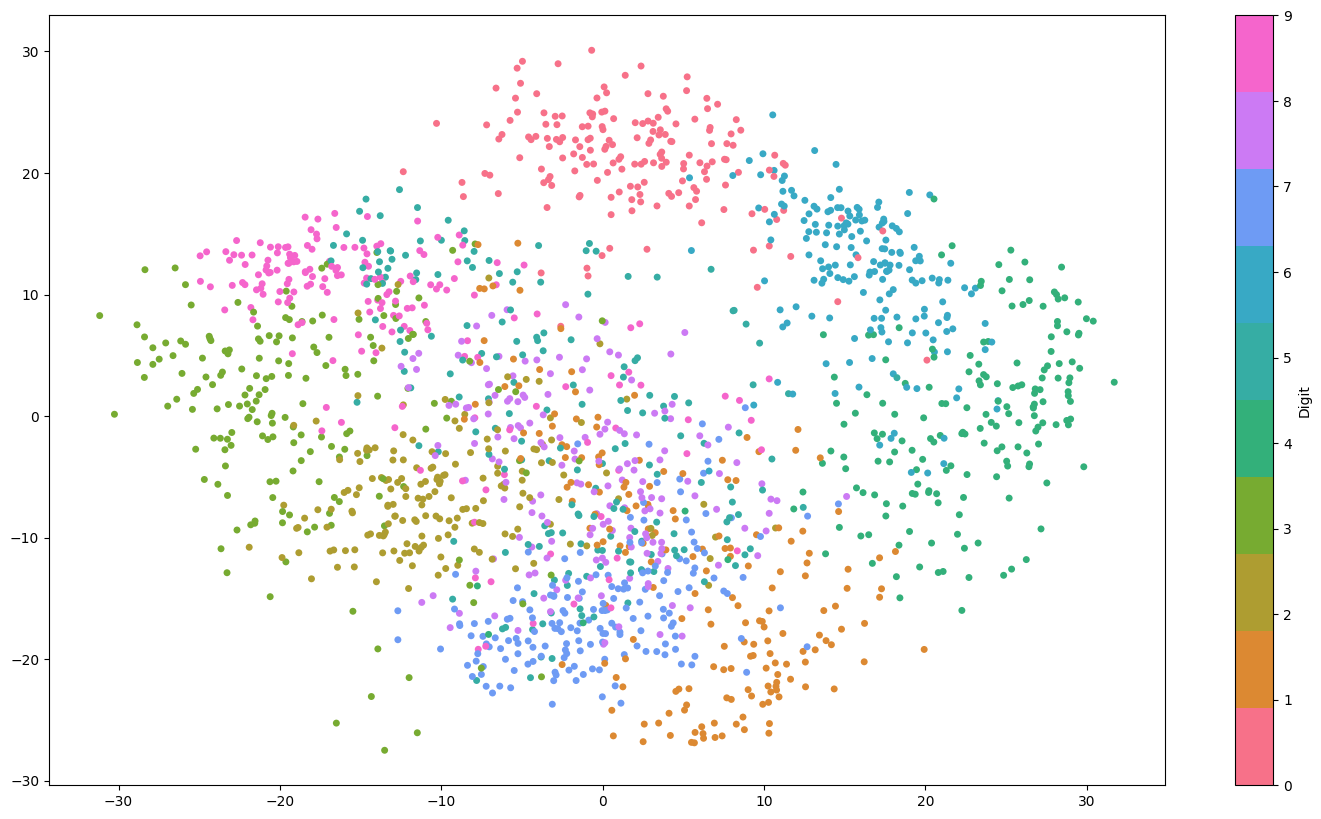

In [ ]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.husl_palette(len(np.unique(Y))))
fig, ax = plt.subplots()

"""
  on x-axis we use 0th dimension of z1
  on y-axis we use 1th dimension of z1
"""

im = ax.scatter(Z1[:,0], Z1[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

In [ ]:
# total Variance preserved by 2 components
print(pca_2D.explained_variance_ratio_)
print(pca_2D.explained_variance_ratio_.sum())

[0.14890594 0.13618771]
0.2850936482369202


### tSNE

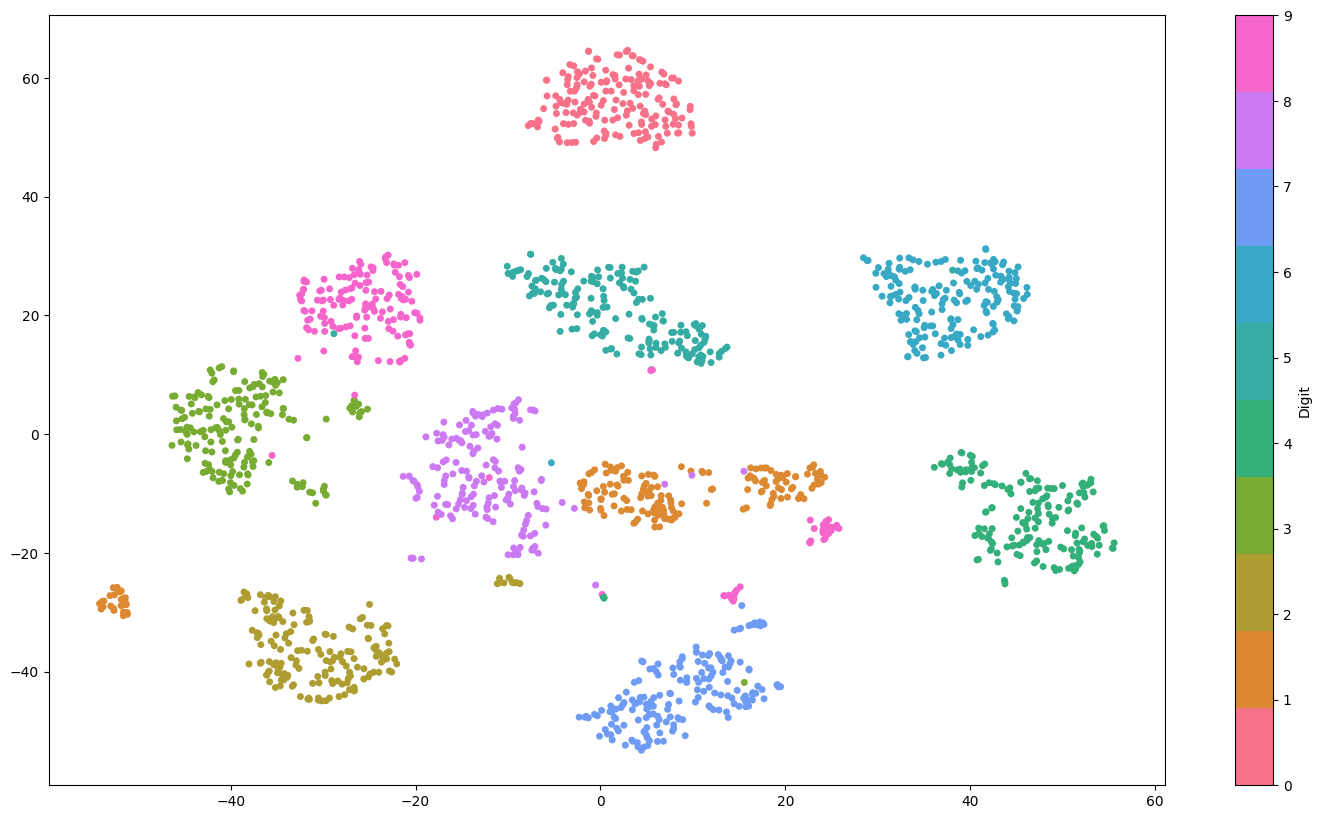

In [ ]:
from sklearn.manifold import TSNE

z2 = TSNE(n_components=2, random_state=0, perplexity=25).fit_transform(X)
fig, ax = plt.subplots()
im = ax.scatter(z2[:,0], z2[:,1], s=25, c=Y, cmap=cmap, edgecolor='none')
cbar = fig.colorbar(im, ax=ax,label='Digit')

In [ ]:
#-distributed Stochastic Neighbourhood Embedding (tSNE) is good for visualisation but not feature selection